In [1]:
import os
os.makedirs(r"C:\temp\joblib", exist_ok=True)
os.environ["JOBLIB_TEMP_FOLDER"] = r"C:\temp\joblib"  # 영문 경로

# 교차 검증과 그리드 서치

## 검증 세트
- 테스트 세트로 사용해서 성능을 확인하는 작업을 반복하다 보면 점점 모델은 테스트 세트에 맞추게 됩니다.

테슽 세트의 점수를 높이기 위해 모델의 하이퍼파라미터(설정값)를 계속 수정하다 보면, 모델이 실제 데이터의 규칙을 배우는 게 아니라 테스트 세트에만 딱 맞게(Overfitting) 변해버립니다.

- 테스트 세트는 마지막에 한 번만 사용하는 것이 좋습니다.

- 테스트 세트를 사용하지 않고 모델의 과대적합이나 과소적합 여부를 확인하기 위해  
**훈련 데이터를 다시 나누어 검증에 사용하는 데이터**를 검증 세트(validation set)라고 합니다.

In [2]:
import pandas as pd

wine = pd.read_csv('data/wine.csv')

In [3]:
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()
print(data.shape)

(6497, 3)


In [4]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [5]:
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

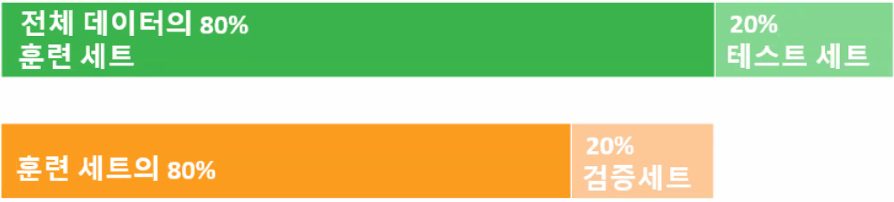

In [6]:
print(train_input.shape, test_input.shape, sub_input.shape, val_input.shape)
# scikit-learn은 test 쪽을 크게 잡아 정수로 맞춤
# test_input.shape  => 6497*0.2 = 1299.4 => 1300
# train_input.shape => 6497 - 1300 = 5197

# val_input.shape   => 5197*0.2 = 1039.4 => 1040
# sub_input.shape   => 5197 - 1040 = 4157

(5197, 3) (1300, 3) (4157, 3) (1040, 3)


In [7]:
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(random_state=42)
dt1.fit(sub_input, sub_target)

print(dt1.score(sub_input, sub_target))
print(dt1.score(val_input, val_target))

0.9971133028626413
0.864423076923077


훈련 정확도는 매우 높고, 검증 정확도는 상대적으로 낮게 나타납니다.  
→ 훈련 데이터에 대해서는 거의 완벽한 예측을 수행하지만, 새로운 데이터에 대한 일반화 성능은 떨어집니다.

모델이 지나치게 복잡하여 훈련 데이터에만 최적화된 상태입니다.
→ 데이터의 전반적인 패턴보다는 개별 샘플과 잡음(noise)까지 학습한 결과입니다.

Decision Tree(결정트리, 의사결정나무)는 분기를 반복적으로 생성하여 불순도(Gini 또는 Entropy)를 0에 가깝게 만들려는 모델입니다.  
제약 조건이 없을 경우, 트리의 깊이에 제한이 없고 리프 노드에 샘플이 1개만 있어도 분기를 생성합니다.  
→ 훈련 데이터에 대해서는 거의 완벽한 성능을 보이게 됩니다.

이로 인해 의사결정나무의 대표적인 문제인 과대적합(overfitting) 현상이 발생했습니다.

---

## 교차 검증(cross validation)
- 교차 검증은 검증 세트를 떼어 내여 평가하는 과정을 여러 번 반복합니다.
- 그 다음 이 점수를 평균을 낸 뒤 최종 검증 점수를 계산합니다.
- 훈련 세트를 세 부분으로 나눠서 교차 검증을 수행하는 것을 3-폴드 교차 검증이라고 합니다.
    - 폴드란 전체 데이터를 K개료 균등하게 나눈 각 부분을 의미하며 훈련 세트와 검증 세트를 만들기 위해 사용하는 데이터 블록 단위 입니다.

    - 교차 검증의 기본 폴드는 5입니다.

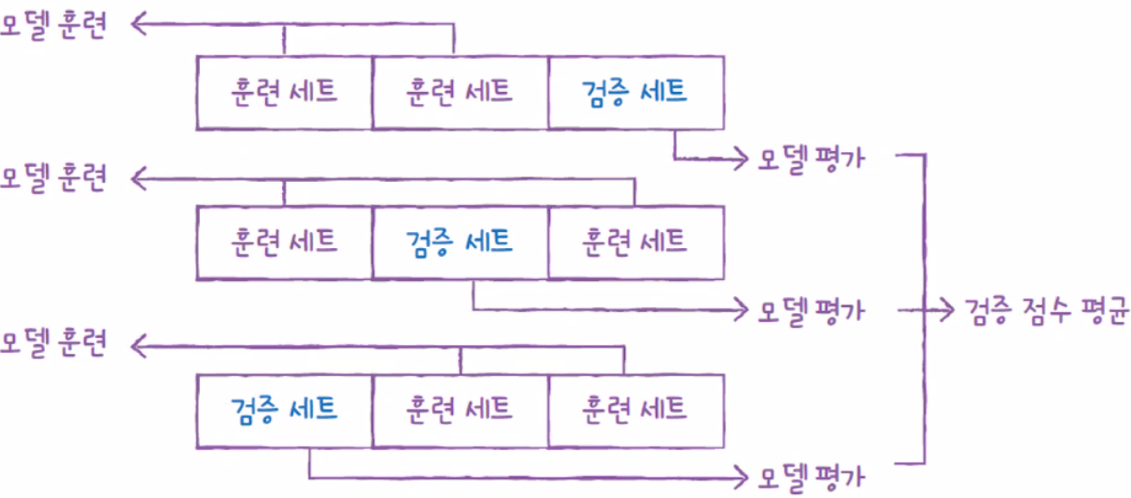



In [8]:
from sklearn.model_selection import cross_validate

# cross_validate() : 데이터를 여러 개의 폴드로 나누어 반복적으로 훈련과 검증을 수행합니다.
# dt1: 사용할 모델
# train_input, train_target: 훈련용 데이터와 정답
# 반환값은 각 폴드 별 훈련 및 검증 점수를 담은 dict
# cv 매개 변수에서 폴드 수 변경 가능. 기본은 5
scores = cross_validate(dt1, train_input, train_target)

print(scores)
# 각 키의 의미
# fit_time: 각각 모델을 학습하는데 걸린 시간
# score_time: 성능 평가에 걸린 시간
# test_score: 각 폺드의 검증 세트 점수 

{'fit_time': array([0.0029974 , 0.00130081, 0.00400805, 0.0040071 , 0.00200438]), 'score_time': array([0.0010004 , 0.0029099 , 0.        , 0.        , 0.00200367]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}


In [9]:
import numpy as np

print(np.mean(scores['test_score']))

0.855300214703487


---

## 분할기를 사용한 교차 검증
- 층화 K-폴드 교차 검즈(Stratified K-Fold Cross Validation) 을 사용합니다.

- 일반 K-Fold는 단순히 데이터를 K개의 조각으로 나누지만, StratifiedKFold는 각 폴드마다 클래스 비율(예: 양성/음성 비율) 이 전체 데이터와 비슷하게 유지되도록 나눕니다.

- 사이킷런(scikit-learn)의 StratifiedKFold()를 별도의 인자 없이 기본값으로 호출했을 때 기본값

    | **매개변수 (Parameter)** | **기본값 (Default)** | **의미** |
    | :--- | :--- | :--- |
    | `n_splits` | 5 | 데이터를 5개의 폴드로 나눕니다. (5-겹 교차 검증) |
    | `shuffle` | False | 데이터를 나누기 전에 섞지 않습니다. 입력된 순서대로 폴드를 구성합니다. |
    | `random_state` | None | 난수 시드가 없습니다. `shuffle=False` 일 때는 의미가 없습니다. |

In [10]:
from sklearn.model_selection import StratifiedKFold

splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_validate(dt1, train_input, train_target, cv=splitter)
print(np.mean(scores['test_score']))

0.8574181117533719


---

## 하이퍼파라미터 튜닝
- 모델 파라미터 : 머신러닝 모델이 학습하는 파라미터

    - 예) coef_, intercept_ : 선형 회귀(LinearRegression)에서 회귀선의 기울기(가중치)와 절편

- 하이퍼파라미터 : 모델이 학습할 수 없어 사용자가 지정해야 하는 파라미터

    - 예) alpha: 선형 회귀에서 Ridge, Lasso에서 규제의 강도를 조절하는 파라미터
    - 예) max_depth: 결정트리 (DecisionTreeClassifier)에서 트리의 최대 깊이 조절하는 파라미터

- 하이퍼파라미터 튜닝 작업 진행

    1. 라이브러리가 제공하는 기본 값을 그대로 사용해 모델을 학습
    2. 검증 세트의 점수나 교차 검증을 통해서 매개변수를 조금씩 바꿈
    3. 모델마다 여러개의 매개변수를 제공
    4. 매개변수를 바꿔가면서 모델을 훈련하고 교차 검증을 수행

 ---
## 그리드 서치(Grid Search)

- **그리드 서치(Grid Search)** 는 머신러닝에서 **하이퍼파라미터 탐색과 교차 검증을 한 번에 수행하는 방법**입니다.
- 여러 하이퍼파라미터 후보 값들을 **격자(grid) 형태로 나열**하고, 가능한 **모든 조합을 전부 탐색**하여 가장 성능이 좋은 조합을 찾습니다.
- 여기서 '격자'란 바둑판처럼 가로줄과 세로줄이 교차된 **표 형태**를 의미하며,  
그리드 서치는 **하이퍼파라미터 조합을 표처럼 모두 나열하여 탐색한다는 의미**입니다.

---

### 특징
- 모든 조합을 시도하므로 **탐색 결과가 안정적입니다.**
- 하이퍼파라미터 조합 수가 많아질수록 **연산 비용이 증가**합니다.
- 각 조합은 일반적으로 **교차 검증(Cross Valication)** 을 통해 평가됩니다.

---
### 예시
- 결정트리 모델에서 다음과 같은 하이퍼파라미터 후보가 있다고 가정합니다.

- max_depth = [3, 5, 7] # max_depth는 루트 노드(Root Node)부터 리프 노드(Leaf Node)까지의 최대 깊이

- min_sample_split = [2, 5] # min_sample_split: 노드를 분할하기 위해 필요한 최소 샘플 수

- 가능한 하이퍼파라미터 조합은 다음과 같습니다.

    - (3, 2)
    - (3, 5)
    - (5, 2)
    - (5, 5)
    - (7, 2)
    - (7, 5)

**→ 총 6개의 조합**

- 그리드 서치는 이 **모든 조합에 대해 교차 검증을 수행**하고,  
평균 성능이 가장 좋은 조합을 **최종 하이퍼파라미터로 선택**합니다.

> 그리드 서치는 모든 하이퍼파라미터 조합을 교차 검증으로 평가하여 가장 성능이 좋은 조합을 찾는 방법입니다.

In [11]:
# 기본 매개변수를 사용한 결정 트리 모델에서 min_impurity_decrease 매개변수의 최적값을 찾기 위한 설정입니다.

# min_impurity_decrease
# 특정 노드를 분할했을 때 감소되는 불순도(Impurity)의 최소 기준값으로 분할로 인한 불순도 감소량이 이 값보다 크거나 같을 때만
# 노드 분할이 허용되며, 값이 클수록 트리 성장은 제한됩니다.
from sklearn.model_selection import GridSearchCV

params = {'min_impurity_decrease': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}

# min_impurity_decrease 값을 점점 크게 하면 트리의 분기 수가 줄어들어 과대적합을 완화하는 효과가 있습니다.

In [12]:
# Scikit-learn 라이브러리를 사용하여 결정 트리(Decision Tree) 모델의 최적 하이퍼파라미터를 찾기 위한 GridSearchCV 설정입니다.

# DecisionTreeClassifier(random_state=42)
# 결정 트리 분류 모델을 생성하며, random_state를 고정하여 실행 결과를 항상 동일하게 재현할 수 있도록 설정합니다.

# params : 탐색할 하이퍼파라미터의 후보 범위를 딕셔너리 형태로 지정합니다.

# n_jobs = -1
# Gridc Search 과정에서 사용할 CPU 코어 수를 지정합니다. -1은 사용 가능한 모든 CPU 코어를 사용하여 병렬 처리하겠다는 의미입니다.

# cv=5 (기본값)
# 5-폴드 교차 검증을 수행하여 각 하이퍼파라미터 조합의 성능을 평가합니다.
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)

In [13]:
gs.fit(train_input, train_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'min_impurity_decrease': [0.0001, 0.0002, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

---

In [15]:
dt = gs.best_estimator_
print(dt)

print(dt.score(train_input, train_target))

DecisionTreeClassifier(min_impurity_decrease=0.0001, random_state=42)
0.9615162593804117


In [16]:
print(gs.best_params_)

{'min_impurity_decrease': 0.0001}


In [17]:
print(gs.cv_results_) # 교차 검증 결과 dict

# mean_test_score : 각 하이퍼파라미터 조합에 대한 교차 검증 평균 성능
# std_test_score: 교차 검증 성능의 표준편차
# rank_test_score : 성능 기준 순위
# params : 각 실험에 사용된 하이퍼파라미터 조합
# split0_test_score, split1_test_score : 각 교차 검증 폴드에서의 개별 성능 점수

{'mean_fit_time': array([0.00552478, 0.00422015, 0.00437374, 0.00368381, 0.00238504]), 'std_fit_time': array([0.00048803, 0.0009828 , 0.00041902, 0.00059386, 0.00215146]), 'mean_score_time': array([0.00190768, 0.00120573, 0.00120597, 0.00122094, 0.00293851]), 'std_score_time': array([0.00019996, 0.00098447, 0.00098467, 0.00099714, 0.0030348 ]), 'param_min_impurity_decrease': masked_array(data=[0.0001, 0.0002, 0.0003, 0.0004, 0.0005],
             mask=[False, False, False, False, False],
       fill_value=1e+20), 'params': [{'min_impurity_decrease': 0.0001}, {'min_impurity_decrease': 0.0002}, {'min_impurity_decrease': 0.0003}, {'min_impurity_decrease': 0.0004}, {'min_impurity_decrease': 0.0005}], 'split0_test_score': array([0.86923077, 0.87115385, 0.86923077, 0.86923077, 0.86538462]), 'split1_test_score': array([0.86826923, 0.86346154, 0.85961538, 0.86346154, 0.86923077]), 'split2_test_score': array([0.8825794 , 0.87680462, 0.87584216, 0.88161694, 0.8825794 ]), 'split3_test_score': arr

In [18]:
print(gs.cv_results_['params'])

[{'min_impurity_decrease': 0.0001}, {'min_impurity_decrease': 0.0002}, {'min_impurity_decrease': 0.0003}, {'min_impurity_decrease': 0.0004}, {'min_impurity_decrease': 0.0005}]


In [19]:
print(gs.cv_results_['mean_test_score'])

[0.86819297 0.86453617 0.86492226 0.86780891 0.86761605]


 ---
##### result를 이용해서 모든 조합 중 최고 평균 점수와 최적의 파라미터 조합 구하기
##### 힌트) 넘파이 이용해서 'mean_test_score'의 값이 가장 큰 인덱스를 찾습니다.

In [26]:
result = gs.cv_results_
best_index = np.argmax(result['mean_test_score'])

print(f"최고 점수의 인덱스: {best_index}")
print(f"최고 평균 점수: {result['mean_test_score'][best_index]}")
print(f"최적의 파라미터 조합: {gs.cv_results_['params'][best_index]}")

최고 점수의 인덱스: 0
최고 평균 점수: 0.8681929740134745
최적의 파라미터 조합: {'min_impurity_decrease': 0.0001}


In [27]:
# 복잡한 매개변수 조합 정의

# min_impurity_decrease : 노드를 분할했을 때 불순도가 이 값 이상 감소해야만 분할합니다
# np.arange(0.0001, 0.001, 0.0001) : 0.0001부터 0.0009까지 0.0001씩 증가하는 값 (총 9개)

# max_depth : 트리의 최대 깊이를 제한합니다
# range(5, 20, 1) : 5부터 19까지 1씩 증가

# min_samples_split : 노드를 불할하기 위해 필요한 최소 샘플 수 입니다.
# range(2, 100, 10) : 2부터 92까지 10씩 증가

params = {
    'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
    'max_depth': range(5, 20, 1),
    'min_samples_split': range(2, 100, 10)
}

print(params)

{'min_impurity_decrease': array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008,
       0.0009]), 'max_depth': range(5, 20), 'min_samples_split': range(2, 100, 10)}


In [28]:
gs2 = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs2.fit(train_input, train_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(5, 20), 'min_impurity_decrease': array([0.0001... 0.0009]), 'min_samples_split': range(2, 100, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [30]:
print(gs2.best_params_)

{'max_depth': 14, 'min_impurity_decrease': np.float64(0.0004), 'min_samples_split': 12}


In [31]:
print(np.max(gs2.cv_results_['mean_test_score']))

0.8683865773302731


## 랜덤 서치 (Random Search)

- 그리드 서치(Grid Search)는 지정한 모든 하이퍼파라미터 조합을 **전수 조사**하여 최적의 조합을 찾는 방법입니다.

- 램던 서치(Random Search)는 하이퍼파라미터 조합을 **무작위로 추출하여 평가**하는 방법입니다.

### 랜덤 서치를 사용하는 경우

- 매개변수 값이 **연속적인 수치**인 경우 → 값의 범위나 간격을 미리 촘촘하게 정하기 어려운 경우

- **매개변수의 개수가 많아** 그리드 서치 수행 시간이 지나치게 오래 걸리는 경우

- **제한된 시간 안에서 좋은 성능의 하이퍼파라미터 조합을 빠르게 찾고 싶은 경우**

### 특징

- 랜덤 서치에서는 **매개변수 값 목록(list)** 대신 **매개변수를 샘플링할 수 있는 확률 분포 객체**를 사용할 수 있습니다.

- 예를 들어 `scipy.stats`의 분포를 사용하여 지정한 범위에서 **무작위로 값을 샘플링**할 수 있습니다.

### 정리

- 랜덤 서치는 모든 조합을 탐색하지 않고 **확률적으로 일부 조합만 평가하여 시간 대비 효율적으로 좋은 하이퍼파라미터를 찾는 방법**입니다.

In [32]:
# scipy.stats는 확률분포(Probability Distribution) 관련 함수를 제공하는 모듈입니다.
# uniform - 연속형 균등분포로 지정한 구간 안에서 모든 실수 값이 동일한 확률로 선택됩ㄴ디ㅏ.
# randint - 정수형 균등분포로 지정한 정수 범위 안에서 모든 정수가 동일한 확률로 선택됩니다.
from scipy.stats import uniform, randint

In [33]:
rgen = randint(0, 10)

# rvs()는 "Random Variates Sample"의 약자입니다.
# 이 확률 분포에서 임의의 표본(Sample)을 생성하는 함수입니다.
# 10은 생성할 표본의 개수(size)를 의미합니다.

rgen.rvs(10)

# 실행마다 결과가 달라집니다.

array([2, 6, 4, 7, 6, 0, 1, 2, 3, 5])

In [34]:
np.unique(rgen.rvs(1000), return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([107,  89, 111,  97,  87,  91, 103, 116, 103,  96]))

In [35]:
ugen = uniform(0, 1)
ugen.rvs(10)

array([0.62779441, 0.90588656, 0.57349855, 0.27415401, 0.58000599,
       0.93807632, 0.82469043, 0.90606589, 0.60438343, 0.75709539])

In [36]:
params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25)
          }

In [37]:
from sklearn.model_selection import RandomizedSearchCV

# n_iter=100: params에서 정의한 분포들로부터 하이퍼파라미터 조합을 100번 랜덤 추출하여 각 조합마다 교차 검증을 수행합니다.
gs3 = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
                         params,
                         n_iter=100, n_jobs=-1,
                         random_state=42)

gs3.fit(train_input, train_target)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....002A5934E32F0>, 'min_impurity_decrease': <scipy.stats....002A5929D8EF0>, 'min_samples_leaf': <scipy.stats....002A592D036B0>, 'min_samples_split': <scipy.stats....002A592D03230>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User G

In [38]:
print(gs3.best_params_)

{'max_depth': 39, 'min_impurity_decrease': np.float64(0.00034102546602601173), 'min_samples_leaf': 7, 'min_samples_split': 13}


In [39]:
print(np.max(gs3.cv_results_['mean_test_score']))

0.8695428296438884


In [40]:
dt = gs3.best_estimator_

print(dt.score(test_input, test_target))

0.86
